In [1]:
import os
# === FORCE CPU - NO GPU PROBLEMS ===
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable GPU completely
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # No TF spam

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.backend.clear_session()
print("✅ CPU-only mode - No GPU errors")
print(f"TF version: {tf.__version__}")

✅ CPU-only mode - No GPU errors
TF version: 2.20.0


In [2]:
# MNIST loading
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize + CNN shape
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)  # (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, -1)    # (10000, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"✅ Train: {x_train.shape} | Test: {x_test.shape}")

✅ Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)


In [3]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    
    # Conv blocks
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    
    # Classifier
    layers.Flatten(), layers.Dropout(0.5),
    layers.Dense(64, activation='relu'), layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_MNIST')

model.summary()

2026-02-27 23:08:50.446670: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_data=(x_test, y_test),
                    verbose=1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.8324 - loss: 0.5210 - val_accuracy: 0.9731 - val_loss: 0.0869
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9517 - loss: 0.1679 - val_accuracy: 0.9820 - val_loss: 0.0549
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9668 - loss: 0.1180 - val_accuracy: 0.9875 - val_loss: 0.0396
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9718 - loss: 0.0991 - val_accuracy: 0.9883 - val_loss: 0.0364
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9775 - loss: 0.0841 - val_accuracy: 0.9892 - val_loss: 0.0313
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9786 - loss: 0.0740 - val_accuracy: 0.9902 - val_loss: 0.0318
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9809 - loss: 0.0668 - val_accuracy: 0.9903 - val_loss: 0.0298
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9820 - loss: 0.0622 - 

🎉 Test accuracy: 0.9929 (99.29%)


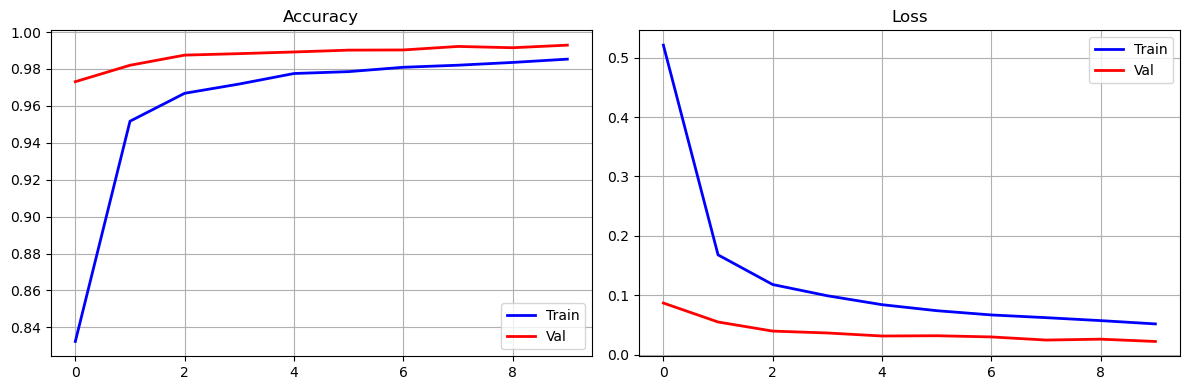

In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"🎉 Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], 'b-', label='Train', lw=2)
plt.plot(history.history['val_accuracy'], 'r-', label='Val', lw=2)
plt.title('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], 'b-', label='Train', lw=2)
plt.plot(history.history['val_loss'], 'r-', label='Val', lw=2)
plt.title('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='cnn.png', show_shapes=True, show_layer_names=True)
print("✅ Model diagram saved")

✅ Model diagram saved
